In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from matplotlib import rcParams
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Arial"]
rcParams["font.size"] = 10
rcParams["axes.linewidth"] = 0.8
rcParams["xtick.major.width"] = 0.8
rcParams["ytick.major.width"] = 0.8
rcParams["xtick.major.size"] = 3
rcParams["ytick.major.size"] = 3
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42

/Users/linrisheng/miniconda3/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/linrisheng/miniconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/linrisheng/miniconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/linrisheng/miniconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return module_get_attr_redirect(attr_name, deprecated_ma

In [2]:
adata = sc.read_10x_h5('./filtered_feature_bc_matrix.h5', gex_only=False)

/Users/linrisheng/miniconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
adata_gex = adata[:, adata.var['feature_types'] == 'Gene Expression'].copy()

/Users/linrisheng/miniconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
print(adata_gex)

AnnData object with n_obs × n_vars = 44551 × 33696
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'target_gene_id', 'target_gene_name'


In [5]:
import pandas as pd

csv_path = "./protospacer_calls_per_cell_single_sgRNA.csv"
df = pd.read_csv(csv_path, sep=None, engine="python")
df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()
df["cell_barcode"] = df["cell_barcode"].astype(str).str.strip()
df = df.drop_duplicates(subset=["cell_barcode"]).copy()
df = df[df["cell_barcode"].isin(adata_gex.obs_names)].copy()
adata_sg = adata_gex[df["cell_barcode"].values, :].copy()
df2 = df.set_index("cell_barcode")
adata_sg.obs["sgRNA_call"] = df2.loc[adata_sg.obs_names, "feature_call"].astype(str).values

print(adata_sg)
print(adata_sg.obs[["sgRNA_call"]].head())


AnnData object with n_obs × n_vars = 4983 × 33696
    obs: 'sgRNA_call'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'target_gene_id', 'target_gene_name'
                   sgRNA_call
AAACCTGTCGTAGATC-1   sgFam50a
AAACGGGCAGGCTGAA-1   sgFam50a
AAACGGGGTGATAAGT-1   sgFam50a
AAACGGGTCGCACTCT-1   sgFam50a
AAAGTAGCACATAACC-1   sgFam50a


/Users/linrisheng/miniconda3/lib/python3.12/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata_sg.var_names_make_unique()
sc.pp.filter_cells(adata_sg, min_genes=500)  
sc.pp.filter_genes(adata_sg, min_cells=100)
adata_sg.var['mt'] = adata_sg.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata_sg, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)  
adata_sg = adata_sg[adata_sg.obs.pct_counts_mt < 5, :]

In [7]:
print(adata_sg)

View of AnnData object with n_obs × n_vars = 4983 × 13248
    obs: 'sgRNA_call', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'target_gene_id', 'target_gene_name', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


In [8]:
adata_sg.layers["raw_counts"] = adata_sg.X.copy()
sc.pp.normalize_total(adata_sg, target_sum=1e4)  
sc.pp.log1p(adata_sg)  

/var/folders/7m/l5wyj1b51fb_0wq6spg2q6kw0000gn/T/ipykernel_4347/2403904459.py:1: ImplicitModificationWarning: Setting element `.layers['raw_counts']` of view, initializing view as actual.
  adata_sg.layers["raw_counts"] = adata_sg.X.copy()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/linrisheng/miniconda3/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/linrisheng/miniconda3/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:209: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
/Users/linrisheng/miniconda3/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
/Users/linri

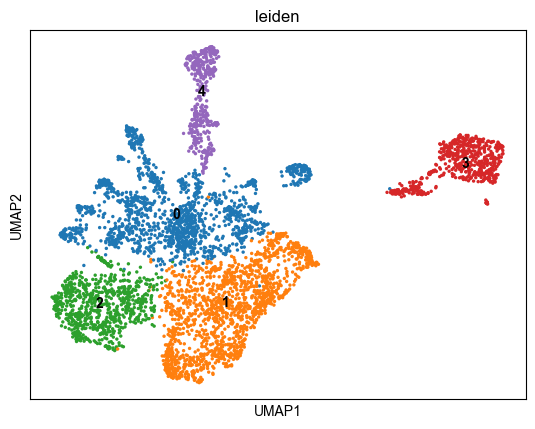

In [9]:
sc.pp.highly_variable_genes(adata_sg, flavor="cell_ranger", n_top_genes=3000)
adata_sg.raw = adata_sg.copy()
sc.tl.pca(adata_sg, svd_solver="arpack", n_comps=50, use_highly_variable=True)
sc.pp.neighbors(adata_sg, n_neighbors=30, n_pcs=10)
sc.tl.leiden(adata_sg, resolution=0.1)
sc.tl.umap(adata_sg, min_dist=0.3, random_state=0)
sc.pl.umap(adata_sg, color=["leiden"], legend_loc="on data")

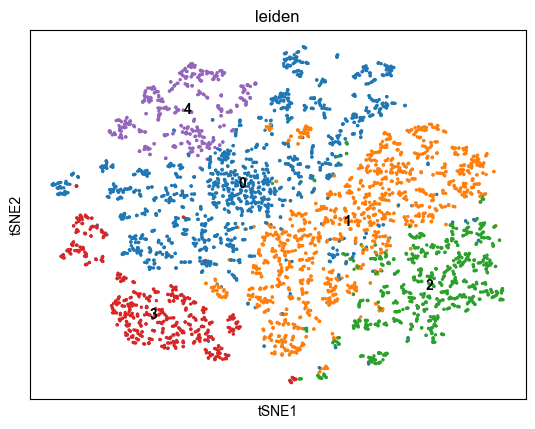

In [10]:

sc.tl.tsne(adata_sg, use_rep="X_pca", perplexity=5, learning_rate=200, random_state=0)
sc.pl.tsne(adata_sg, color=["leiden"], legend_loc="on data")

🔬 Input data has 4983 cells and 13248 genes
🔗 Matching reference genes in the model
🧬 2449 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 39 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'I', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'X', 'a', 'b', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'r', 's', 'six', 'slash', 'space', 't', 'three', 'two', 'underscore', 'v', 'y']
Glyph IDs:   [0, 1, 2, 3, 16, 18, 20, 21, 22, 23, 24, 25, 36, 38, 40, 44, 47, 48, 49, 51, 54, 55, 56, 59, 66, 68, 69, 74, 76, 77, 79, 80, 81, 82, 85, 86, 87, 89, 92]
Closed glyph list over 'GSUB': 39 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'I', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'X', 'a', 'b', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'r', 's', 'six', 'slash', 'space', 't', 'three', 'two', 'underscore', 'v', 'y']
Gl

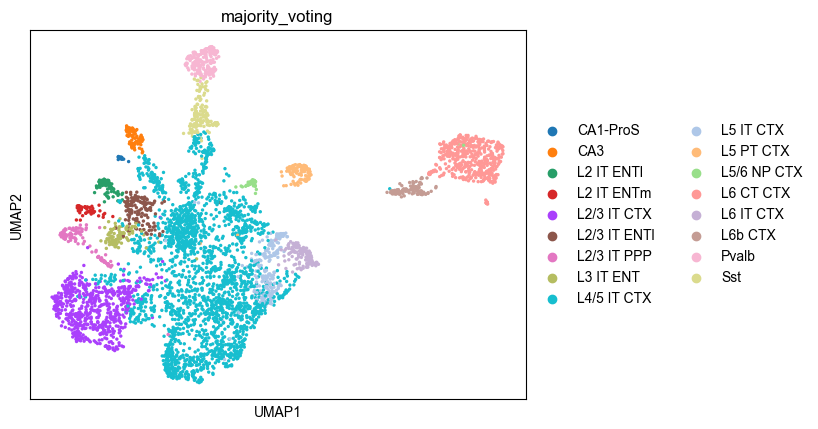

maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 42 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'I', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'X', 'a', 'b', 'd', 'e', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'r', 's', 'six', 'slash', 'space', 't', 'three', 'two', 'underscore', 'v', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 16, 18, 19, 20, 21, 22, 23, 24, 25, 36, 38, 40, 44, 47, 48, 49, 51, 54, 55, 56, 59, 66, 68, 69, 71, 72, 74, 76, 77, 79, 80, 81, 82, 85, 86, 87, 89, 92]
Closed glyph list over 'GSUB': 42 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'I', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'X', 'a', 'b', 'd', 'e', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'r', 's', 'six', 'slash', 'space', 't', 't

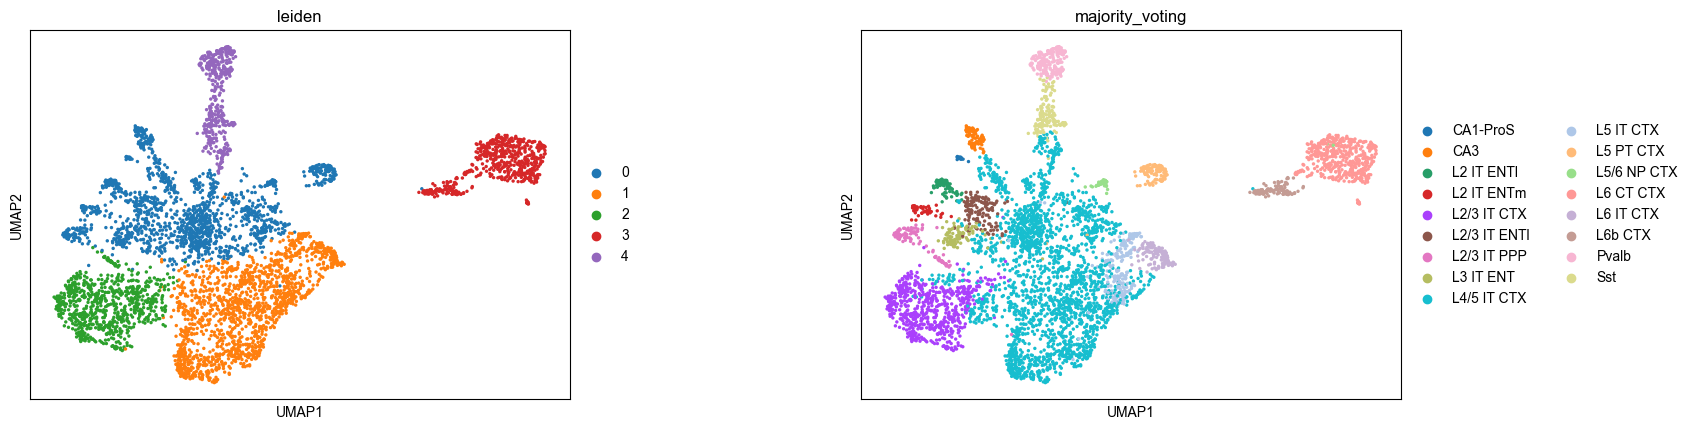

maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 23 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'c', 'e', 'eight', 'f', 'four', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'six', 'space', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 23, 25, 27, 36, 48, 51, 56, 66, 70, 72, 73, 81, 82, 85, 86]
Closed glyph list over 'GSUB': 23 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'c', 'e', 'eight', 'f', 'four', 'n', 'nonmarkingreturn', 'o', 'one', 'period', 'r', 's', 'six', 'space', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 23, 25, 27, 36, 48, 51, 56, 66, 70, 72, 73, 81, 82, 85, 86]
Closing glyph list over 'glyf': 23 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'c', 'e', 'eight', 'f', 'four

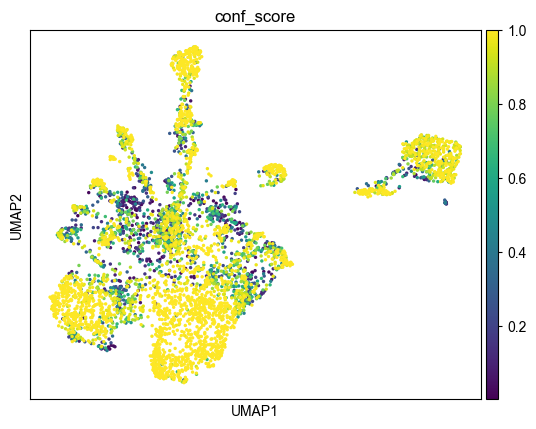

In [11]:
import scanpy as sc
import celltypist

# CellTypist
model = celltypist.models.Model.load(
    model="./Mouse_Isocortex_Hippocampus.pkl"
)

pred = celltypist.annotate(
    adata_sg,
    model=model,
    majority_voting=True
)


pred.to_adata(adata_sg)

# UMAP 
sc.pl.umap(adata_sg, color="majority_voting", save="majority_voting.pdf")

sc.pl.umap(
    adata_sg,
    color=["leiden", "majority_voting"],
    wspace=0.4, save="leiden_majority_voting.pdf"
 
)
sc.pl.umap(
    adata_sg,
    color="conf_score",
    cmap="viridis", save="conf_score.pdf"
   
)


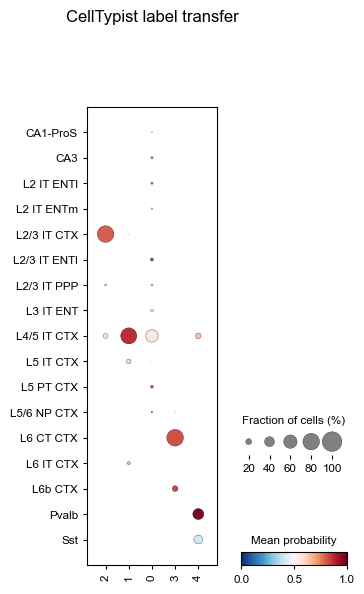

In [12]:
celltypist.dotplot(pred, use_as_reference = 'leiden', use_as_prediction = 'majority_voting')

In [13]:
import re

def celltype_coarse(label):
    label = str(label).strip()

    # -------------------------
    # 1) Inhibitory interneurons
    # -------------------------
    inhibitory_markers = ["Lamp5", "Pvalb", "Sst", "Vip", "Sncg", "Gad1", "Gad2"]
    if any(label.startswith(x) for x in inhibitory_markers) or label.endswith("Gaba"):
        return "Inhibitory interneurons"

    # -------------------------
    # 2) Hippocampal neurons
    # -------------------------
    hippocampal_markers = ["CA1", "CA1-ProS", "CA2-IG-FC", "CA3", "DG", "Car3", "ProS" , "SUB-ProS"]
    if any(label.startswith(x) for x in hippocampal_markers):
        return "Hippocampal neurons"

    # -------------------------
    # 3) Cortical excitatory: superficial layers
    #    L2 / L2/3 / L3
    # -------------------------
    if re.match(r"^L(2|2/3|3)\b", label):
        return "Sup.-layer neurons"

    # -------------------------
    # 4) Cortical excitatory: deep layers
    #    L4/5 / L5 / L5/6 / L6 / L6b
    # -------------------------
    if re.match(r"^L(4/5|5|5/6|6|6b)\b", label):
        return "Deep-layer neurons"


    return "Other"



In [14]:
adata_sg.obs["celltype_coarse"] = (
    adata_sg.obs["majority_voting"]
    .apply(celltype_coarse)
)
print(adata_sg.obs.columns.tolist())

['sgRNA_call', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'celltype_coarse']


... storing 'celltype_coarse' as categorical


maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 33 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'D', 'H', 'I', 'M', 'P', 'S', 'U', 'a', 'b', 'c', 'e', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'space', 't', 'two', 'u', 'underscore', 'y']
Glyph IDs:   [0, 1, 2, 3, 16, 17, 20, 21, 36, 39, 43, 44, 48, 51, 54, 56, 66, 68, 69, 70, 72, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92]
Closed glyph list over 'GSUB': 33 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'D', 'H', 'I', 'M', 'P', 'S', 'U', 'a', 'b', 'c', 'e', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'space', 't', 'two', 'u', 'underscore', 'y']
Glyph IDs:   [0, 1, 2, 3, 16, 17, 20, 21, 36, 39, 43, 44, 48, 51, 54, 56, 66, 68, 69, 70, 72, 75, 76, 79, 80

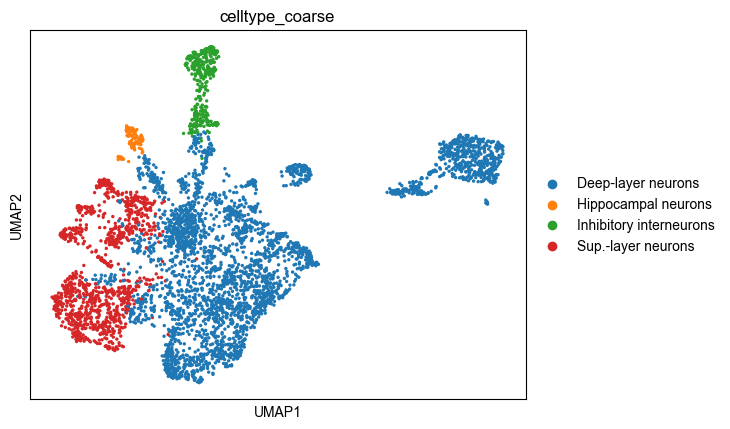

In [15]:
sc.pl.umap(adata_sg,color="celltype_coarse",  save="celltype_coarse.pdf")

maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 28 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'F', 'M', 'N', 'P', 'R', 'U', 'a', 'c', 'five', 'four', 'g', 'l', 'm', 'nine', 'nonmarkingreturn', 'one', 's', 'seven', 'six', 'space', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 28, 36, 38, 41, 48, 49, 51, 53, 56, 66, 68, 70, 74, 79, 80, 86]
Closed glyph list over 'GSUB': 28 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'F', 'M', 'N', 'P', 'R', 'U', 'a', 'c', 'five', 'four', 'g', 'l', 'm', 'nine', 'nonmarkingreturn', 'one', 's', 'seven', 'six', 'space', 'three', 'two', 'underscore', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 28, 36, 38, 41, 48, 49, 51, 53, 56, 66, 68, 70, 74, 79, 80, 86]
Closing glyph list over 'glyf': 

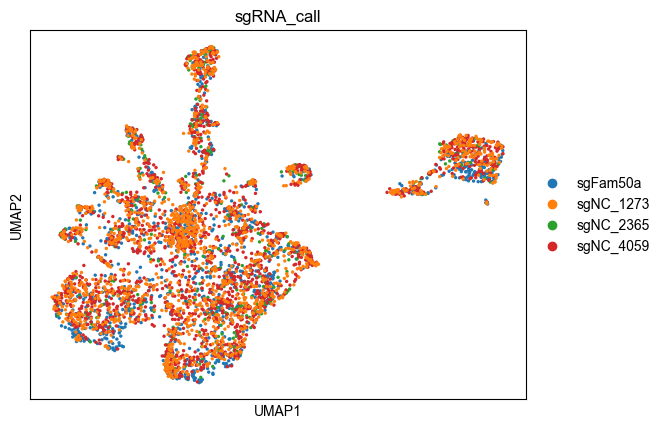

In [16]:
sc.pl.umap(
    adata_sg,
    color="sgRNA_call",
    groups=["sgFam50a", "sgNC_1273", "sgNC_2365", "sgNC_4059"],   # ← 你要标记的群名
    wspace=0.4, save="sgRNA_call.pdf"
)

In [17]:
print(adata_sg)

AnnData object with n_obs × n_vars = 4983 × 13248
    obs: 'sgRNA_call', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'celltype_coarse'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'target_gene_id', 'target_gene_name', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'tsne', 'over_clustering', 'majority_voting_colors', 'celltype_coarse_colors', 'sgRNA_call_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'


In [18]:


adata_sg.obs["target"] = np.where(adata_sg.obs["sgRNA_call"] == "sgFam50a", "sgFam50a", "NTC")
adata_sg.obs["target"].value_counts()
adata_sg.obs[["sgRNA_call", "target"]].head()


,sgRNA_call,target
AAACCTGTCGTAGATC-1,sgFam50a,sgFam50a
AAACGGGCAGGCTGAA-1,sgFam50a,sgFam50a
AAACGGGGTGATAAGT-1,sgFam50a,sgFam50a
AAACGGGTCGCACTCT-1,sgFam50a,sgFam50a
AAAGTAGCACATAACC-1,sgFam50a,sgFam50a


In [19]:
print(adata_sg)

AnnData object with n_obs × n_vars = 4983 × 13248
    obs: 'sgRNA_call', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'celltype_coarse', 'target'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'target_gene_id', 'target_gene_name', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'tsne', 'over_clustering', 'majority_voting_colors', 'celltype_coarse_colors', 'sgRNA_call_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'


maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 50 glyphs before
Glyph names: ['.notdef', '.null', 'C', 'D', 'F', 'H', 'I', 'M', 'N', 'P', 'S', 'T', 'a', 'b', 'c', 'e', 'eight', 'equal', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'plus', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'x', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 11, 12, 14, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 32, 38, 39, 41, 43, 44, 48, 49, 51, 54, 55, 68, 69, 70, 72, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92]
Closed glyph list over 'GSUB': 50 glyphs after
Glyph names: ['.notdef', '.null', 'C', 'D', 'F', 'H', 'I', 'M', 'N', 'P', 'S', 'T', 'a', 'b', 'c', 'e', 'eight', 'equal', 'five', 'four', 'g', 'h

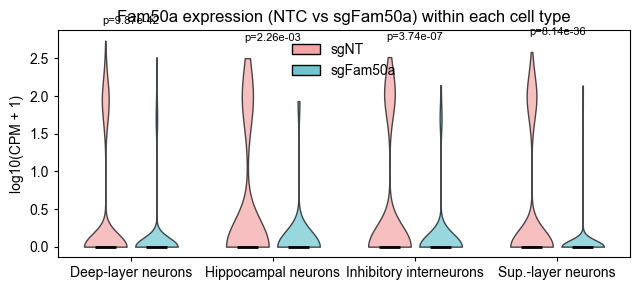

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind

gene = "Fam50a"
group_col = "target"
celltype_col = "celltype_coarse"


targets = adata_sg.obs[group_col].astype(str).unique().tolist()
fam_group = "sgFam50a" if "sgFam50a" in targets else "Fam50a"
groups_keep = ["NTC", fam_group]

adata_sub = adata_sg[adata_sg.obs[group_col].isin(groups_keep)].copy()

# ===== raw_counts -> CPM -> log10(CPM+1) =====
X_counts = adata_sub.layers["raw_counts"]
total_counts = np.array(X_counts.sum(axis=1)).flatten()


if gene not in adata_sub.var_names:
    hit = [g for g in adata_sub.var_names if g.upper() == gene.upper()]
    if len(hit) == 0:
        raise ValueError(f"{gene} 不在 var_names 里")
    gene = hit[0]

gene_idx = np.where(adata_sub.var_names == gene)[0][0]
gene_counts = X_counts[:, gene_idx]
gene_counts = gene_counts.toarray().flatten() if hasattr(gene_counts, "toarray") else np.array(gene_counts).flatten()

cpm = gene_counts / total_counts * 1e6
log10_cpm1 = np.log10(cpm + 1)

df = pd.DataFrame({
    "celltype": adata_sub.obs[celltype_col].astype(str).values,
    "group": adata_sub.obs[group_col].astype(str).values,
    "expr": log10_cpm1
})

celltypes = sorted(df["celltype"].unique().tolist())


fig, ax = plt.subplots(figsize=(1.5 * len(celltypes) + 0.5, 3))

datasets = []
positions = []
colors = []


offset = 0.18
width = 0.3


color_ntc = "#F4A6A6"   
color_fam = "#6EC6D1"  

for i, ct in enumerate(celltypes):
    sub = df[df["celltype"] == ct]

    data_ntc = sub[sub["group"] == "NTC"]["expr"].values
    data_fam = sub[sub["group"] == fam_group]["expr"].values

    # ===== t-test =====
    pval = None
    if len(data_ntc) > 1 and len(data_fam) > 1:
        stat, pval = ttest_ind(data_ntc, data_fam, equal_var=False)


    pos_center = i + 1
    pos_ntc = pos_center - offset
    pos_fam = pos_center + offset

    if len(data_ntc) > 0:
        datasets.append(data_ntc)
        positions.append(pos_ntc)
        colors.append(color_ntc)

    if len(data_fam) > 0:
        datasets.append(data_fam)
        positions.append(pos_fam)
        colors.append(color_fam)
        
    if pval is not None:
        y_max = max(
            np.max(data_ntc) if len(data_ntc) > 0 else 0,
            np.max(data_fam) if len(data_fam) > 0 else 0
        )
        ax.text(
            pos_center,
            y_max + 0.2,
            f"p={pval:.2e}",
            ha="center",
            va="bottom",
            fontsize=8
        )

vp = ax.violinplot(
    datasets,
    positions=positions,
    widths=width,
    showmeans=False,
    showmedians=True,
    showextrema=False
)


for body, c in zip(vp["bodies"], colors):
    body.set_facecolor(c)
    body.set_edgecolor("black")
    body.set_alpha(0.7)


vp["cmedians"].set_color("black")
vp["cmedians"].set_linewidth(2)


ax.set_xticks(range(1, len(celltypes) + 1))
ax.set_xticklabels(celltypes)

ax.set_ylabel("log10(CPM + 1)")
ax.set_title(f"{gene} expression (NTC vs {fam_group}) within each cell type")


legend_handles = [
    Patch(facecolor=color_ntc, edgecolor="black", label="sgNT"),
    Patch(facecolor=color_fam, edgecolor="black", label="sgFam50a"),
]
ax.legend(handles=legend_handles, frameon=False)

plt.tight_layout()
plt.savefig("./figures/Expressioin_level.pdf", bbox_inches="tight")
plt.savefig("./figures/Expressioin_level.png", dpi=300, bbox_inches="tight")
plt.show()

maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 44 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'F', 'H', 'I', 'N', 'R', 'S', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 36, 38, 39, 41, 43, 44, 49, 53, 54, 66, 68, 69, 70, 71, 72, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92]
Closed glyph list over 'GSUB': 44 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'F', 'H', 'I', 'N', 'R', 'S', 'a', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 

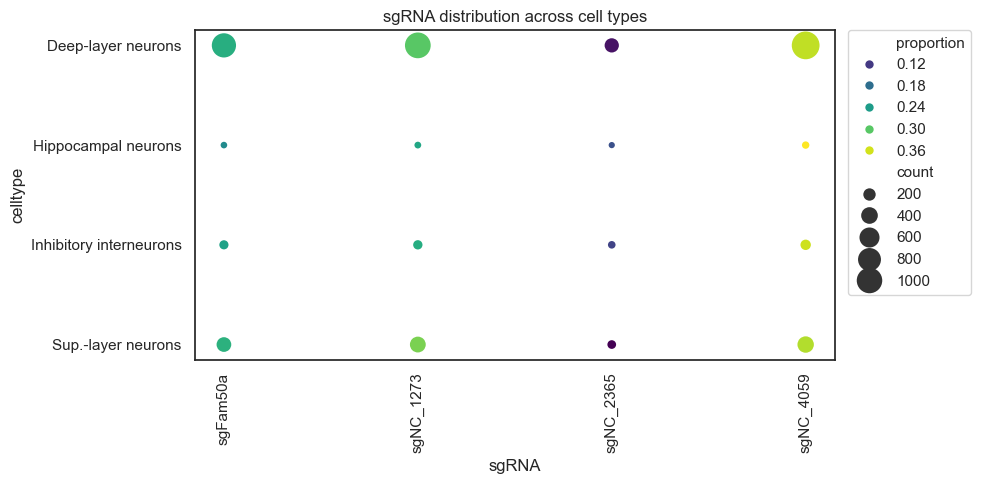

Saved to: ./figures/sgRNA_distribution_across_cell_types.pdf


In [37]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


outdir = "./figures"
os.makedirs(outdir, exist_ok=True)


count_table = pd.crosstab(
    adata_sg.obs["celltype_coarse"],
    adata_sg.obs["sgRNA_call"]
)

prop_table = count_table.div(count_table.sum(axis=1), axis=0)


plot_df = count_table.stack().reset_index()
plot_df.columns = ["celltype", "sgRNA", "count"]

prop_df = prop_table.stack().reset_index()
prop_df.columns = ["celltype", "sgRNA", "proportion"]

# 合并 count + proportion
plot_df = plot_df.merge(prop_df, on=["celltype", "sgRNA"], how="left")


plot_df = plot_df[plot_df["count"] > 0].copy()


sgrna_order = count_table.sum(axis=0).sort_values(ascending=False).index
plot_df["sgRNA"] = pd.Categorical(plot_df["sgRNA"], categories=sgrna_order, ordered=True)


celltype_order = count_table.sum(axis=1).sort_values(ascending=False).index
plot_df["celltype"] = pd.Categorical(plot_df["celltype"], categories=celltype_order, ordered=True)


sns.set(style="white")  

plt.figure(figsize=(10, 5))
ax = sns.scatterplot(
    data=plot_df,
    x="sgRNA",
    y="celltype",
    size="count",          
    hue="proportion",        
    sizes=(20, 400),
    palette="viridis",
    linewidth=0
)

ax.set_title("sgRNA distribution across cell types")
ax.set_xlabel("sgRNA")
ax.set_ylabel("celltype")

plt.xticks(rotation=90)


ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=True
)

plt.tight_layout()


outfile = os.path.join(outdir, "sgRNA_distribution_across_cell_types.pdf")
plt.savefig(outfile, bbox_inches="tight")
plt.show()

print(f"Saved to: {outfile}")

In [38]:
# ============================================================
# 单细胞水平 DEG：sgFam50a vs NTC，按 celltype_coarse 分层
# 不再做 pseudobulk；直接在单细胞层面用 Scanpy Wilcoxon rank-sum test
# 输入要求：adata_sg 已完成 QC、normalize_total、log1p，并含有 raw_counts layer
# ============================================================

import os
import numpy as np
import pandas as pd
import scanpy as sc

# ---------- 参数 ----------
outdir = "./single_cell_DEG"
os.makedirs(outdir, exist_ok=True)

group_col = "target"              # 比较分组列
celltype_col = "celltype_coarse"  # 细胞类型列
sg_col = "sgRNA_call"             # sgRNA 列
case_sg = "sgFam50a"              # 目标 sgRNA
case_label = "Fam50a"             # 输出中使用的目标组名
ctrl_label = "NTC"                # 对照组名

min_cells_per_group = 20           # 每个 cell type 内每组至少多少细胞才做 DEG
min_pct_expr = 0.05                # 至少在任一组中 >5% 细胞表达才保留
max_padj = 0.05                    # 输出显著 DEG 阈值
min_abs_logfc = 0.25               # 输出显著 DEG 阈值

# ---------- 构建 target 分组 ----------
# 这里保持你的逻辑：sgFam50a 为扰动组，其余作为 NTC。
# 如果你只想把 sgNC_1273/2365/4059 作为 NTC，而不是所有非 sgFam50a 细胞，见下方可选写法。
adata_sg.obs[group_col] = np.where(
    adata_sg.obs[sg_col].astype(str) == case_sg,
    case_label,
    ctrl_label
)

# 可选：如果只想使用指定 non-targeting sgRNA 作为 NTC，请取消下面几行注释
# ntc_sgs = ["sgNC_1273", "sgNC_2365", "sgNC_4059"]
# keep = adata_sg.obs[sg_col].isin([case_sg] + ntc_sgs)
# adata_sg = adata_sg[keep].copy()
# adata_sg.obs[group_col] = np.where(adata_sg.obs[sg_col].astype(str) == case_sg, case_label, ctrl_label)

# ---------- 确保用于 DEG 的矩阵是 log-normalized expression ----------
# 你的 notebook 里已经做过：
# adata_sg.layers["raw_counts"] = adata_sg.X.copy()
# sc.pp.normalize_total(adata_sg, target_sum=1e4)
# sc.pp.log1p(adata_sg)
# 因此这里默认 adata_sg.X 就是 log1p(normalized counts)。

all_deg = []
summary_rows = []

for ct in sorted(adata_sg.obs[celltype_col].astype(str).unique()):
    ad_ct = adata_sg[adata_sg.obs[celltype_col].astype(str) == ct].copy()

    n_case = int((ad_ct.obs[group_col] == case_label).sum())
    n_ctrl = int((ad_ct.obs[group_col] == ctrl_label).sum())

    summary_rows.append({
        "celltype": ct,
        "n_case": n_case,
        "n_ctrl": n_ctrl,
        "tested": n_case >= min_cells_per_group and n_ctrl >= min_cells_per_group
    })

    if n_case < min_cells_per_group or n_ctrl < min_cells_per_group:
        print(f"跳过 {ct}: {case_label}={n_case}, {ctrl_label}={n_ctrl}，低于 min_cells_per_group={min_cells_per_group}")
        continue

    # 只保留两个组
    ad_ct = ad_ct[ad_ct.obs[group_col].isin([case_label, ctrl_label])].copy()
    ad_ct.obs[group_col] = ad_ct.obs[group_col].astype("category")
    ad_ct.obs[group_col] = ad_ct.obs[group_col].cat.reorder_categories([ctrl_label, case_label])

    # 过滤低表达基因：任一组表达细胞比例达到 min_pct_expr
    X = ad_ct.X
    if hasattr(X, "toarray"):
        detected = X > 0
        pct_case = np.asarray(detected[ad_ct.obs[group_col].values == case_label].mean(axis=0)).ravel()
        pct_ctrl = np.asarray(detected[ad_ct.obs[group_col].values == ctrl_label].mean(axis=0)).ravel()
    else:
        detected = X > 0
        pct_case = detected[ad_ct.obs[group_col].values == case_label].mean(axis=0)
        pct_ctrl = detected[ad_ct.obs[group_col].values == ctrl_label].mean(axis=0)

    keep_gene = (pct_case >= min_pct_expr) | (pct_ctrl >= min_pct_expr)
    ad_ct = ad_ct[:, keep_gene].copy()

    # Wilcoxon 单细胞 DEG：case_label vs ctrl_label
    sc.tl.rank_genes_groups(
        ad_ct,
        groupby=group_col,
        groups=[case_label],
        reference=ctrl_label,
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        tie_correct=True,
        pts=True,
        use_raw=False
    )

    deg = sc.get.rank_genes_groups_df(ad_ct, group=case_label)
    deg.insert(0, "celltype", ct)
    deg.insert(1, "contrast", f"{case_label}_vs_{ctrl_label}")
    deg.insert(2, "n_case", n_case)
    deg.insert(3, "n_ctrl", n_ctrl)

    # Scanpy 输出中的 logfoldchanges 是近似 log2FC，基于 log-normalized 数据估计
    deg = deg.rename(columns={
        "names": "gene",
        "scores": "score",
        "pvals": "pval",
        "pvals_adj": "padj",
        "logfoldchanges": "log2FC"
    })

    # 单个 cell type 单独保存
    safe_ct = ct.replace("/", "_").replace(" ", "_")
    deg.to_csv(os.path.join(outdir, f"DEG_{safe_ct}_{case_label}_vs_{ctrl_label}.csv"), index=False)
    all_deg.append(deg)

# ---------- 合并输出 ----------
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(outdir, "celltype_cell_counts_for_DEG.csv"), index=False)

if len(all_deg) == 0:
    raise ValueError("没有任何 celltype 满足 min_cells_per_group，请降低阈值或检查 target/celltype 分组。")

all_deg = pd.concat(all_deg, axis=0, ignore_index=True)
all_deg.to_csv(os.path.join(outdir, f"all_celltypes_DEG_{case_label}_vs_{ctrl_label}.csv"), index=False)

sig_deg = all_deg[
    (all_deg["padj"] < max_padj) &
    (all_deg["log2FC"].abs() >= min_abs_logfc)
].copy()
sig_deg.to_csv(os.path.join(outdir, f"significant_DEG_padj{max_padj}_log2FC{min_abs_logfc}.csv"), index=False)

print("✅ 单细胞水平 DEG 完成")
print("输出目录:", os.path.abspath(outdir))
print("总 DEG 表:", os.path.join(outdir, f"all_celltypes_DEG_{case_label}_vs_{ctrl_label}.csv"))
print("显著 DEG 表:", os.path.join(outdir, f"significant_DEG_padj{max_padj}_log2FC{min_abs_logfc}.csv"))
print("各 celltype 细胞数:", os.path.join(outdir, "celltype_cell_counts_for_DEG.csv"))
print("显著 DEG 数量:", sig_deg.shape[0])


✅ 单细胞水平 DEG 完成
输出目录: /Users/linrisheng/Library/CloudStorage/OneDrive-个人/invivo/10x/pRS050-perturb-seq-3targets/Fam50a/for_github/in_vivo_Perturb-seq_for_revision/single_cell_DEG
总 DEG 表: ./single_cell_DEG/all_celltypes_DEG_Fam50a_vs_NTC.csv
显著 DEG 表: ./single_cell_DEG/significant_DEG_padj0.05_log2FC0.25.csv
各 celltype 细胞数: ./single_cell_DEG/celltype_cell_counts_for_DEG.csv
显著 DEG 数量: 3478


In [39]:
# ============================================================
# 可选：按 cell type 画 volcano plot，并标注 top genes
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

outdir = "./single_cell_DEG"
plotdir = os.path.join(outdir, "volcano")
os.makedirs(plotdir, exist_ok=True)

all_deg_path = os.path.join(outdir, "all_celltypes_DEG_Fam50a_vs_NTC.csv")
all_deg = pd.read_csv(all_deg_path)

padj_cutoff = 0.05
logfc_cutoff = 0.25
top_n_label = 10

for ct, df in all_deg.groupby("celltype"):
    df = df.copy()
    df["minus_log10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))
    df["sig"] = (df["padj"] < padj_cutoff) & (df["log2FC"].abs() >= logfc_cutoff)

    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.scatter(
        df["log2FC"],
        df["minus_log10_padj"],
        s=6,
        alpha=0.6
    )

    ax.axvline(logfc_cutoff, linestyle="--", linewidth=0.8)
    ax.axvline(-logfc_cutoff, linestyle="--", linewidth=0.8)
    ax.axhline(-np.log10(padj_cutoff), linestyle="--", linewidth=0.8)

    label_df = df[df["sig"]].sort_values("padj").head(top_n_label)
    for _, r in label_df.iterrows():
        ax.text(r["log2FC"], r["minus_log10_padj"], str(r["gene"]), fontsize=7)

    ax.set_title(ct)
    ax.set_xlabel("log2FC: Fam50a vs NTC")
    ax.set_ylabel("-log10 adjusted P")
    fig.tight_layout()

    safe_ct = str(ct).replace("/", "_").replace(" ", "_")
    fig.savefig(os.path.join(plotdir, f"volcano_{safe_ct}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(plotdir, f"volcano_{safe_ct}.png"), dpi=300, bbox_inches="tight")
    plt.close(fig)

print("✅ Volcano plots saved to:", os.path.abspath(plotdir))


maxp pruned
LTSH dropped
cmap pruned
kern dropped
post pruned
PCLT dropped
JSTF dropped
DSIG dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 48 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'F', 'G', 'M', 'N', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 36, 38, 39, 41, 42, 48, 49, 51, 53, 54, 55, 68, 69, 70, 71, 72, 73, 74, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 92, 237]
Closed glyph list over 'GSUB': 48 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'F', 'G', 'M', 'N', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'k', 'l'

✅ Volcano plots saved to: /Users/linrisheng/Library/CloudStorage/OneDrive-个人/invivo/10x/pRS050-perturb-seq-3targets/Fam50a/for_github/in_vivo_Perturb-seq_for_revision/single_cell_DEG/volcano


In [40]:
import pandas as pd


df = adata_sg.obs[['target', 'sgRNA_call', 'celltype_coarse', 'majority_voting']].copy()


df.insert(0, 'cellbarcode', adata_sg.obs_names)


df.to_csv("./cellbarcode_target_sgRNA_celltype.tsv", sep="\t", index=False)


In [41]:
adata_sg.write_h5ad("adata_sg.h5ad",compression="gzip")

... storing 'target' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'sequence' as categorical
... storing 'target_gene_id' as categorical
... storing 'target_gene_name' as categorical


In [42]:
print (adata_sg)

AnnData object with n_obs × n_vars = 4983 × 13248
    obs: 'sgRNA_call', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'celltype_coarse', 'target'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'target_gene_id', 'target_gene_name', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'tsne', 'over_clustering', 'majority_voting_colors', 'celltype_coarse_colors', 'sgRNA_call_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'distances', 'connectivities'


In [43]:
print("X matrix type:", type(adata_sg.X))
print("First few values of X:", adata_sg.X[:5, :5].toarray()) 
print("Raw counts in layers:", 'raw_counts' in adata_sg.layers)

X matrix type: <class 'scipy.sparse._csr.csr_matrix'>
First few values of X: [[3.0962303  0.         0.         0.         0.        ]
 [3.420289   0.         0.41208974 0.         0.        ]
 [2.7922158  0.         0.         0.         0.        ]
 [2.7613437  0.         0.         0.72205    0.        ]
 [3.5037928  0.         1.1249566  0.         0.        ]]
Raw counts in layers: True


In [21]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import os

# ========== 参数 ==========
raw_layer = "raw_counts"
min_cells_per_pb = 10   
out_counts = "11pseudobulk_counts.csv"
out_meta   = "11pseudobulk_metadata.csv"
out_cellmeta = "cell_meta.csv"


if raw_layer not in adata_sg.layers:
    raise ValueError(f"adata_sg.layers 中没有 '{raw_layer}'")


adata_sg.obs["target"] = np.where(adata_sg.obs["sgRNA_call"] == "sgFam50a", "Fam50a", "NTC")



adata_sg.obs["batch"] = adata_sg.obs_names.str.split("-").str[-1]
adata_sg.obs["batch"] = adata_sg.obs["batch"].map({"1": "rep1", "2": "rep2"}).fillna("repX")


group_cols = ["batch", "target", "celltype_coarse"]
for c in group_cols:
    if c not in adata_sg.obs.columns:
        raise ValueError(f"adata_sg.obs 缺少列: {c}")

adata_sg.obs["pb_group_id"] = adata_sg.obs[group_cols].astype(str).agg("|".join, axis=1)


X = adata_sg.layers[raw_layer]
if not sp.issparse(X):
    X = sp.csr_matrix(X)

groups = (
    pd.Series(np.arange(adata_sg.n_obs), index=adata_sg.obs["pb_group_id"])
      .groupby(level=0).apply(list)
)

pb_obs_rows = []
pb_X_list = []

for gid, idx_list in groups.items():
    if len(idx_list) < min_cells_per_pb:
        continue

    summed = np.asarray(X[idx_list, :].sum(axis=0)).ravel()
    batch, target, ct = gid.split("|")

    pb_obs_rows.append({
        "pb_group_id": gid,
        "batch": batch,
        "target": target,
        "celltype_coarse": ct,
        "n_cells": len(idx_list)
    })
    pb_X_list.append(summed)

if len(pb_X_list) == 0:
    raise ValueError("没有任何 pseudobulk 通过 min_cells_per_pb 过滤阈值，请降低 min_cells_per_pb。")

pb_X = sp.csr_matrix(np.vstack(pb_X_list))
pb_obs = pd.DataFrame(pb_obs_rows).set_index("pb_group_id")

adata_pb = ad.AnnData(X=pb_X, obs=pb_obs, var=adata_sg.var.copy())

print("✅ pseudobulk AnnData created:")
print(adata_pb)
print("\nGroups (n_cells):")
print(adata_pb.obs.sort_values("n_cells", ascending=False).head(20))


pb_counts = pd.DataFrame(
    adata_pb.X.toarray(),
    index=adata_pb.obs_names,      
    columns=adata_pb.var_names
)
pb_counts.to_csv(out_counts)
adata_pb.obs.to_csv(out_meta)


cell_meta = adata_sg.obs.copy()
cell_meta.insert(0, "cell_id", adata_sg.obs_names)
cell_meta[["cell_id", "celltype_coarse", "target", "batch"]].to_csv(out_cellmeta, index=False)

print("\n✅ Export finished!")
print("Working dir:", os.getcwd())
print("Saved:")
print(" -", os.path.abspath(out_counts))
print(" -", os.path.abspath(out_meta))
print(" -", os.path.abspath(out_cellmeta))


✅ pseudobulk AnnData created:
AnnData object with n_obs × n_vars = 16 × 13248
    obs: 'batch', 'target', 'celltype_coarse', 'n_cells'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'target_gene_id', 'target_gene_name', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

Groups (n_cells):
                                    batch  target          celltype_coarse  \
pb_group_id                                                                  
rep1|NTC|Deep-layer neurons          rep1     NTC       Deep-layer neurons   
rep2|NTC|Deep-layer neurons          rep2     NTC       Deep-layer neurons   
rep2|NTC|Sup.-layer neurons          rep2     NTC       Sup.-layer neurons   
rep2|Fam50a|Deep-layer neurons       rep2  Fam50a       Deep-layer neurons   
rep1|Fam50a|Deep-layer neurons       rep1  Fam50a       Deep-layer neurons   
rep1|NTC|Sup.-layer neurons